# Mini Project 1: Historical Weather Comparison Across U.S. Cities

This notebook collects historical daily weather data from the Open-Meteo Historical Weather API and uses pandas to compare weather patterns across eight U.S. cities.

The original idea was to compare current weather, but that would only create one row per city. This version uses a full winter season of daily records, so each city has many rows and the analysis can use grouping, filtering, summaries, and missing-data checks.

## Dataset

**Source:** Open-Meteo Historical Weather API  
**API endpoint:** `https://archive-api.open-meteo.com/v1/archive`  
**Date range:** December 1, 2025 through February 28, 2026  
**Cities:** Seattle, Phoenix, Miami, Chicago, New York City, Los Angeles, Denver, and New Orleans

Each row in the dataset represents **one city on one day**.

## Analytical questions

1. Which city had the biggest average difference between actual temperature and “feels like” temperature?
2. Which city had the highest average humidity, and how does Seattle compare to the others?
3. Which cities had the most cloudy, rainy, or clear days, and are there any rough patterns by region?

Because each region is represented by only one city, the regional comparisons should be treated as a rough snapshot rather than a broad claim about each region overall.

## 1. Import libraries

This notebook uses `urllib` and `json` from Python's standard library to request API data, then uses `pandas` to organize and analyze it. `matplotlib` is only used for simple charts.

In [1]:
import json
import time
from pathlib import Path
from urllib.parse import urlencode
from urllib.request import urlopen

import matplotlib.pyplot as plt
import pandas as pd

## 2. Set up the cities and API request

I am using fixed latitude/longitude coordinates instead of a separate geocoding step. That keeps the project simpler and avoids adding another API call just to find city locations.

In [2]:
# Each dictionary stores the city name, a broad region label, and coordinates.
# The region label lets us do a basic regional comparison later, while the coordinates tell the API where to get weather data.
cities = [
    {"city": "Seattle", "state": "WA", "region": "Pacific Northwest", "latitude": 47.6062, "longitude": -122.3321},
    {"city": "Phoenix", "state": "AZ", "region": "Southwest", "latitude": 33.4484, "longitude": -112.0740},
    {"city": "Miami", "state": "FL", "region": "Southeast", "latitude": 25.7617, "longitude": -80.1918},
    {"city": "Chicago", "state": "IL", "region": "Midwest", "latitude": 41.8781, "longitude": -87.6298},
    {"city": "New York City", "state": "NY", "region": "Northeast", "latitude": 40.7128, "longitude": -74.0060},
    {"city": "Los Angeles", "state": "CA", "region": "West Coast", "latitude": 34.0522, "longitude": -118.2437},
    {"city": "Denver", "state": "CO", "region": "Mountain West", "latitude": 39.7392, "longitude": -104.9903},
    {"city": "New Orleans", "state": "LA", "region": "Gulf South", "latitude": 29.9511, "longitude": -90.0715},
]

# I chose a full winter season so the dataset is large enough for meaningful pandas analysis.
# This gives about 90 daily rows per city instead of only one current-weather row per city.
START_DATE = "2025-12-01"
END_DATE = "2026-02-28"

# These daily variables match the questions: temperature, feels-like temperature, humidity, clouds, rain, snow, and wind.
# The API will return one value per day for each selected variable.
daily_variables = [
    "weather_code",
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "apparent_temperature_mean",
    "apparent_temperature_max",
    "apparent_temperature_min",
    "relative_humidity_2m_mean",
    "cloud_cover_mean",
    "precipitation_sum",
    "rain_sum",
    "snowfall_sum",
    "wind_speed_10m_mean",
    "wind_speed_10m_max",
    "wind_gusts_10m_max",
]

BASE_URL = "https://archive-api.open-meteo.com/v1/archive"

## 3. Collect the dataset from Open-Meteo

This cell loops through the eight cities, requests historical daily weather data for each one, and turns the API response into one combined pandas DataFrame.

In [3]:
def fetch_city_weather(city_info):
    """Fetch daily historical weather data for one city and return it as a DataFrame."""

    params = {
        "latitude": city_info["latitude"],
        "longitude": city_info["longitude"],
        "start_date": START_DATE,
        "end_date": END_DATE,
        "daily": ",".join(daily_variables),
        "temperature_unit": "fahrenheit",
        "wind_speed_unit": "mph",
        "precipitation_unit": "inch",
        "timezone": "auto",
    }

    url = f"{BASE_URL}?{urlencode(params)}"

    with urlopen(url) as response:
        data = json.loads(response.read().decode("utf-8"))

    # The API stores the daily values in a nested "daily" dictionary.
    # Turning that dictionary into a DataFrame creates one row per day for this city.
    city_df = pd.DataFrame(data["daily"])

    # Add city details to every row so the combined dataset still knows which city each day belongs to.
    city_df["city"] = city_info["city"]
    city_df["state"] = city_info["state"]
    city_df["region"] = city_info["region"]
    city_df["latitude"] = city_info["latitude"]
    city_df["longitude"] = city_info["longitude"]

    return city_df


all_city_dfs = []

for city in cities:
    print(f"Fetching weather data for {city['city']}...")
    city_weather = fetch_city_weather(city)
    all_city_dfs.append(city_weather)

    # A tiny pause is polite to the API and makes it less likely that repeated runs will hit request limits.
    time.sleep(0.2)

weather_df = pd.concat(all_city_dfs, ignore_index=True)

print(f"Collected {len(weather_df)} rows and {len(weather_df.columns)} columns.")
weather_df.head()

Fetching weather data for Seattle...
Fetching weather data for Phoenix...
Fetching weather data for Miami...
Fetching weather data for Chicago...
Fetching weather data for New York City...
Fetching weather data for Los Angeles...
Fetching weather data for Denver...
Fetching weather data for New Orleans...
Collected 720 rows and 21 columns.


,time,weather_code,temperature_2m_mean,temperature_2m_max,temperature_2m_min,apparent_temperature_mean,apparent_temperature_max,apparent_temperature_min,relative_humidity_2m_mean,cloud_cover_mean,...,rain_sum,snowfall_sum,wind_speed_10m_mean,wind_speed_10m_max,wind_gusts_10m_max,city,state,region,latitude,longitude
0,2025-12-01,51,41.3,45.3,37.1,37.4,41.4,33.0,86,85,...,0.008,0.0,2.2,5.0,10.1,Seattle,WA,Pacific Northwest,47.6062,-122.3321
1,2025-12-02,61,44.3,48.0,40.9,40.4,43.3,37.7,88,65,...,0.157,0.0,4.0,7.3,16.1,Seattle,WA,Pacific Northwest,47.6062,-122.3321
2,2025-12-03,51,43.1,45.5,40.5,40.0,42.9,36.9,92,100,...,0.016,0.0,2.0,4.3,7.6,Seattle,WA,Pacific Northwest,47.6062,-122.3321
3,2025-12-04,55,44.4,46.3,42.6,40.2,43.6,37.8,93,100,...,0.508,0.0,5.6,9.1,16.3,Seattle,WA,Pacific Northwest,47.6062,-122.3321
4,2025-12-05,63,49.8,55.2,45.8,43.6,48.1,41.2,90,96,...,0.579,0.0,12.9,22.5,43.4,Seattle,WA,Pacific Northwest,47.6062,-122.3321


## 4. Save a local CSV copy

This makes the dataset easier to reuse. After the API data is collected once, the notebook saves a CSV file in a `data` folder.

In [4]:
data_folder = Path("data")
data_folder.mkdir(exist_ok=True)

csv_path = data_folder / "open_meteo_historical_weather_daily.csv"
weather_df.to_csv(csv_path, index=False)

print(f"Saved dataset to: {csv_path}")

Saved dataset to: data/open_meteo_historical_weather_daily.csv


## 5. Load the dataset with pandas

This step reloads the CSV copy so the analysis starts from a clear dataset file, not just a temporary variable from the API request.

In [5]:
df = pd.read_csv(csv_path)

# Convert the time column into a true date type so pandas can sort, filter, and group it more reliably.
df["time"] = pd.to_datetime(df["time"])

df.head()

,time,weather_code,temperature_2m_mean,temperature_2m_max,temperature_2m_min,apparent_temperature_mean,apparent_temperature_max,apparent_temperature_min,relative_humidity_2m_mean,cloud_cover_mean,...,rain_sum,snowfall_sum,wind_speed_10m_mean,wind_speed_10m_max,wind_gusts_10m_max,city,state,region,latitude,longitude
0,2025-12-01,51,41.3,45.3,37.1,37.4,41.4,33.0,86,85,...,0.008,0.0,2.2,5.0,10.1,Seattle,WA,Pacific Northwest,47.6062,-122.3321
1,2025-12-02,61,44.3,48.0,40.9,40.4,43.3,37.7,88,65,...,0.157,0.0,4.0,7.3,16.1,Seattle,WA,Pacific Northwest,47.6062,-122.3321
2,2025-12-03,51,43.1,45.5,40.5,40.0,42.9,36.9,92,100,...,0.016,0.0,2.0,4.3,7.6,Seattle,WA,Pacific Northwest,47.6062,-122.3321
3,2025-12-04,55,44.4,46.3,42.6,40.2,43.6,37.8,93,100,...,0.508,0.0,5.6,9.1,16.3,Seattle,WA,Pacific Northwest,47.6062,-122.3321
4,2025-12-05,63,49.8,55.2,45.8,43.6,48.1,41.2,90,96,...,0.579,0.0,12.9,22.5,43.4,Seattle,WA,Pacific Northwest,47.6062,-122.3321


## 6. First look at the data

The assignment asks us to use at least three pandas operations from class. The next few cells use more than three, with plain-English comments explaining what each one tells us.

In [6]:
# df.head() shows the first five rows so I can confirm the data is shaped correctly.
# The answer tells me that each row is one city on one date, with weather measurements stored in columns.
df.head()

,time,weather_code,temperature_2m_mean,temperature_2m_max,temperature_2m_min,apparent_temperature_mean,apparent_temperature_max,apparent_temperature_min,relative_humidity_2m_mean,cloud_cover_mean,...,rain_sum,snowfall_sum,wind_speed_10m_mean,wind_speed_10m_max,wind_gusts_10m_max,city,state,region,latitude,longitude
0,2025-12-01,51,41.3,45.3,37.1,37.4,41.4,33.0,86,85,...,0.008,0.0,2.2,5.0,10.1,Seattle,WA,Pacific Northwest,47.6062,-122.3321
1,2025-12-02,61,44.3,48.0,40.9,40.4,43.3,37.7,88,65,...,0.157,0.0,4.0,7.3,16.1,Seattle,WA,Pacific Northwest,47.6062,-122.3321
2,2025-12-03,51,43.1,45.5,40.5,40.0,42.9,36.9,92,100,...,0.016,0.0,2.0,4.3,7.6,Seattle,WA,Pacific Northwest,47.6062,-122.3321
3,2025-12-04,55,44.4,46.3,42.6,40.2,43.6,37.8,93,100,...,0.508,0.0,5.6,9.1,16.3,Seattle,WA,Pacific Northwest,47.6062,-122.3321
4,2025-12-05,63,49.8,55.2,45.8,43.6,48.1,41.2,90,96,...,0.579,0.0,12.9,22.5,43.4,Seattle,WA,Pacific Northwest,47.6062,-122.3321


In [7]:
# df.info() shows the number of rows, column names, data types, and non-null counts.
# The answer tells me whether pandas recognized the columns correctly and whether any columns are missing lots of values.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   time                       720 non-null    datetime64[us]
 1   weather_code               720 non-null    int64         
 2   temperature_2m_mean        720 non-null    float64       
 3   temperature_2m_max         720 non-null    float64       
 4   temperature_2m_min         720 non-null    float64       
 5   apparent_temperature_mean  720 non-null    float64       
 6   apparent_temperature_max   720 non-null    float64       
 7   apparent_temperature_min   720 non-null    float64       
 8   relative_humidity_2m_mean  720 non-null    int64         
 9   cloud_cover_mean           720 non-null    int64         
 10  precipitation_sum          720 non-null    float64       
 11  rain_sum                   720 non-null    float64       
 12  snowfall_sum       

In [8]:
# df.isnull().sum() counts missing values in each column.
# The answer tells me whether the dataset has gaps that could affect the analysis, especially for humidity, clouds, rain, or feels-like temperature.
df.isnull().sum()

time                         0
weather_code                 0
temperature_2m_mean          0
temperature_2m_max           0
temperature_2m_min           0
apparent_temperature_mean    0
apparent_temperature_max     0
apparent_temperature_min     0
relative_humidity_2m_mean    0
cloud_cover_mean             0
precipitation_sum            0
rain_sum                     0
snowfall_sum                 0
wind_speed_10m_mean          0
wind_speed_10m_max           0
wind_gusts_10m_max           0
city                         0
state                        0
region                       0
latitude                     0
longitude                    0
dtype: int64

## 7. Clean and add useful columns

These new columns make the questions easier to answer:

- `feels_like_gap_f`: how much warmer or colder it felt than the actual mean temperature
- `absolute_feels_like_gap_f`: the size of that difference, ignoring direction
- `weather_condition`: a readable label based on Open-Meteo's numeric weather codes
- `is_rain_day`, `is_cloudy_day`, and `is_clear_day`: simple true/false columns for comparing weather patterns

In [9]:
def classify_weather_code(code):
    """Turn Open-Meteo numeric weather codes into broader readable categories."""

    if pd.isna(code):
        return "Unknown"

    code = int(code)

    if code == 0:
        return "Clear"
    elif code in [1, 2, 3]:
        return "Partly cloudy/cloudy"
    elif code in [45, 48]:
        return "Fog"
    elif code in [51, 53, 55, 56, 57, 61, 63, 65, 66, 67, 80, 81, 82]:
        return "Rain/drizzle"
    elif code in [71, 73, 75, 77, 85, 86]:
        return "Snow"
    elif code in [95, 96, 99]:
        return "Thunderstorm"
    else:
        return "Other"


# This is the directional gap: negative means it felt colder than the actual temperature, positive means it felt warmer.
df["feels_like_gap_f"] = df["apparent_temperature_mean"] - df["temperature_2m_mean"]

# This is the size of the gap regardless of direction, which is useful for finding the biggest difference overall.
df["absolute_feels_like_gap_f"] = df["feels_like_gap_f"].abs()

# This turns the numeric weather code into a category that is easier to read and count.
df["weather_condition"] = df["weather_code"].apply(classify_weather_code)

# These true/false columns let us compare rainy, cloudy, and clear days across cities.
# A rainy day means the city had more than a tiny trace of precipitation.
df["is_rain_day"] = df["precipitation_sum"] > 0.01

# A cloudy day means the average cloud cover was at least 70%.
df["is_cloudy_day"] = df["cloud_cover_mean"] >= 70

# A clear day means the weather code was clear or the average cloud cover was very low.
df["is_clear_day"] = (df["weather_condition"] == "Clear") | (df["cloud_cover_mean"] <= 30)

# Show the new columns to check that the added variables make sense.
df[["time", "city", "temperature_2m_mean", "apparent_temperature_mean", "feels_like_gap_f", "weather_condition", "is_rain_day", "is_cloudy_day", "is_clear_day"]].head()

,time,city,temperature_2m_mean,apparent_temperature_mean,feels_like_gap_f,weather_condition,is_rain_day,is_cloudy_day,is_clear_day
0,2025-12-01,Seattle,41.3,37.4,-3.9,Rain/drizzle,False,True,False
1,2025-12-02,Seattle,44.3,40.4,-3.9,Rain/drizzle,True,False,False
2,2025-12-03,Seattle,43.1,40.0,-3.1,Rain/drizzle,True,True,False
3,2025-12-04,Seattle,44.4,40.2,-4.2,Rain/drizzle,True,True,False
4,2025-12-05,Seattle,49.8,43.6,-6.2,Rain/drizzle,True,True,False


In [10]:
# df['column'].value_counts() counts how often each weather condition appears in the full dataset.
# The answer tells me which broad weather categories were most common across all cities and all winter days.
df["weather_condition"].value_counts()

weather_condition
Partly cloudy/cloudy    376
Rain/drizzle            216
Snow                     83
Clear                    45
Name: count, dtype: int64

# Question 1: Which city had the biggest average difference between actual temperature and “feels like” temperature?

This uses groupby because the question is about each city across the whole date range, not just one day.

In [11]:
# df.groupby('city')[...].mean() groups all daily rows by city and calculates each city's average values.
# The answer tells me which city had the biggest average gap between measured air temperature and experienced/feels-like temperature.
feels_like_by_city = (
    df.groupby("city")[["temperature_2m_mean", "apparent_temperature_mean", "feels_like_gap_f", "absolute_feels_like_gap_f"]]
    .mean()
    .sort_values("absolute_feels_like_gap_f", ascending=False)
)

feels_like_by_city.round(2)

,temperature_2m_mean,apparent_temperature_mean,feels_like_gap_f,absolute_feels_like_gap_f
city,,,,
Chicago,26.85,18.26,-8.60,8.60
New York City,28.40,20.56,-7.85,7.85
Denver,37.96,30.96,-7.01,7.01
Seattle,44.18,38.89,-5.29,5.29
Phoenix,60.89,56.55,-4.35,4.44
New Orleans,57.09,54.68,-2.41,3.90
Miami,68.77,69.47,0.70,3.39
Los Angeles,57.72,56.22,-1.50,1.77


In [12]:
# This pulls out the single city with the largest average absolute feels-like gap.
# The answer is the clearest direct response to Question 1.
biggest_gap_city = feels_like_by_city.index[0]
biggest_gap_value = feels_like_by_city.iloc[0]["absolute_feels_like_gap_f"]

print(f"The city with the biggest average feels-like gap was {biggest_gap_city}, with an average gap of {biggest_gap_value:.2f}°F.")

The city with the biggest average feels-like gap was Chicago, with an average gap of 8.60°F.


In [13]:
# This filter finds Seattle days where it felt at least 5°F colder than the actual mean temperature.
# The answer tells me whether Seattle had many days where wind/humidity/conditions made the weather feel noticeably colder.
seattle_cold_feel_days = df[(df["city"] == "Seattle") & (df["feels_like_gap_f"] <= -5)]

seattle_cold_feel_days[["time", "city", "temperature_2m_mean", "apparent_temperature_mean", "feels_like_gap_f", "wind_speed_10m_mean", "relative_humidity_2m_mean"]].head(10)

,time,city,temperature_2m_mean,apparent_temperature_mean,feels_like_gap_f,wind_speed_10m_mean,relative_humidity_2m_mean
4,2025-12-05,Seattle,49.8,43.6,-6.2,12.9,90
5,2025-12-06,Seattle,50.2,41.9,-8.3,16.4,81
6,2025-12-07,Seattle,50.3,44.7,-5.6,11.5,88
7,2025-12-08,Seattle,52.5,46.4,-6.1,14.6,91
9,2025-12-10,Seattle,55.7,49.0,-6.7,18.7,93
14,2025-12-15,Seattle,53.7,46.7,-7.0,16.5,86
15,2025-12-16,Seattle,51.0,44.4,-6.6,14.5,89
16,2025-12-17,Seattle,47.2,38.6,-8.6,15.2,78
17,2025-12-18,Seattle,47.2,39.7,-7.5,13.5,84
18,2025-12-19,Seattle,42.3,33.9,-8.4,12.9,81


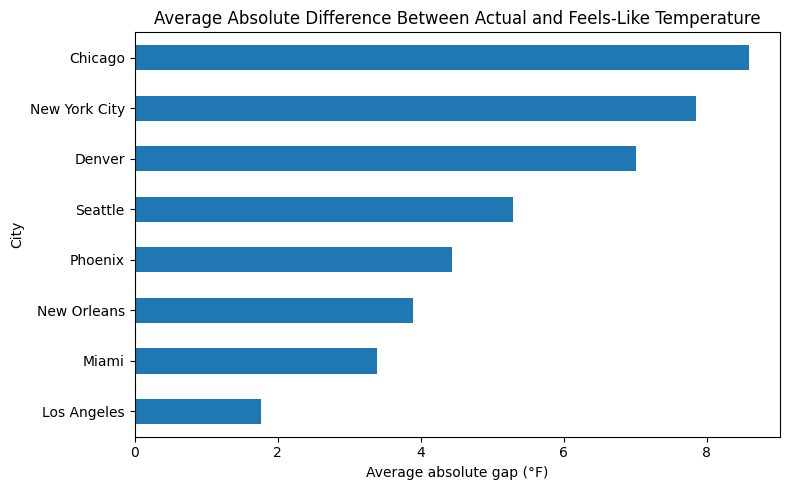

In [14]:
# This chart visualizes the average feels-like gap by city.
# It helps show whether the leading city is a close call or clearly different from the others.
feels_like_by_city["absolute_feels_like_gap_f"].sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Average Absolute Difference Between Actual and Feels-Like Temperature")
plt.xlabel("Average absolute gap (°F)")
plt.ylabel("City")
plt.tight_layout()
plt.show()

# Question 2: Which city had the highest average humidity, and how does Seattle compare?

This question uses average humidity by city, then pulls out Seattle's rank so the comparison is easy to explain.

In [15]:
# This groups the dataset by city and calculates each city's average daily humidity.
# The answer tells me which city was the most humid during the selected winter period.
humidity_by_city = (
    df.groupby("city")["relative_humidity_2m_mean"]
    .mean()
    .sort_values(ascending=False)
)

humidity_by_city.round(2)

city
Seattle          85.04
New Orleans      76.06
Chicago          74.39
Los Angeles      71.47
Miami            71.39
New York City    70.29
Denver           47.82
Phoenix          41.74
Name: relative_humidity_2m_mean, dtype: float64

In [16]:
# This calculates Seattle's rank among the eight cities for average humidity.
# The answer tells me whether Seattle was actually one of the most humid cities in this dataset or whether it only feels that way locally.
seattle_humidity = humidity_by_city.loc["Seattle"]
seattle_rank = humidity_by_city.rank(ascending=False, method="min").loc["Seattle"]

print(f"Seattle's average humidity was {seattle_humidity:.2f}%.")
print(f"Seattle ranked #{int(seattle_rank)} out of {len(humidity_by_city)} cities for average humidity, where #1 is the most humid.")

Seattle's average humidity was 85.04%.
Seattle ranked #1 out of 8 cities for average humidity, where #1 is the most humid.


In [17]:
# This filter shows days where average humidity was above 85%.
# The answer tells me which city-days were especially humid, instead of only looking at citywide averages.
very_humid_days = df[df["relative_humidity_2m_mean"] > 85]

very_humid_days[["time", "city", "region", "relative_humidity_2m_mean", "temperature_2m_mean", "weather_condition"]].head(15)

,time,city,region,relative_humidity_2m_mean,temperature_2m_mean,weather_condition
0,2025-12-01,Seattle,Pacific Northwest,86,41.3,Rain/drizzle
1,2025-12-02,Seattle,Pacific Northwest,88,44.3,Rain/drizzle
2,2025-12-03,Seattle,Pacific Northwest,92,43.1,Rain/drizzle
3,2025-12-04,Seattle,Pacific Northwest,93,44.4,Rain/drizzle
4,2025-12-05,Seattle,Pacific Northwest,90,49.8,Rain/drizzle
6,2025-12-07,Seattle,Pacific Northwest,88,50.3,Rain/drizzle
7,2025-12-08,Seattle,Pacific Northwest,91,52.5,Rain/drizzle
8,2025-12-09,Seattle,Pacific Northwest,87,49.4,Rain/drizzle
9,2025-12-10,Seattle,Pacific Northwest,93,55.7,Rain/drizzle
10,2025-12-11,Seattle,Pacific Northwest,88,49.4,Rain/drizzle


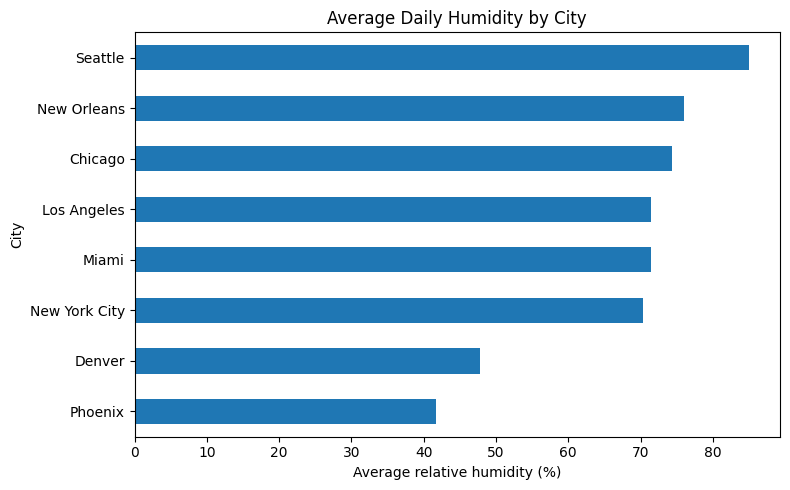

In [18]:
# This chart shows average humidity by city.
# It makes Seattle's position easier to compare visually against the warmer and wetter cities.
humidity_by_city.sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Average Daily Humidity by City")
plt.xlabel("Average relative humidity (%)")
plt.ylabel("City")
plt.tight_layout()
plt.show()

# Question 3: Which cities had the most cloudy, rainy, or clear days?

This question looks at condition counts and percentages so cities can be compared fairly across the same date range.

In [19]:
# This counts how many times each weather condition appears for each city.
# The answer tells me which cities had more clear days, rainy/drizzly days, cloudy days, snow days, and other conditions.
condition_counts_by_city = (
    df.groupby("city")["weather_condition"]
    .value_counts()
    .unstack(fill_value=0)
)

condition_counts_by_city

weather_condition,Clear,Partly cloudy/cloudy,Rain/drizzle,Snow
city,,,,
Chicago,0,40,14,36
Denver,3,64,9,14
Los Angeles,11,57,22,0
Miami,7,31,52,0
New Orleans,8,39,43,0
New York City,3,47,14,26
Phoenix,13,64,13,0
Seattle,0,34,49,7


In [20]:
# This converts condition counts into percentages for each city.
# The answer makes city comparisons easier because it shows the share of days in each condition category.
condition_percent_by_city = condition_counts_by_city.div(condition_counts_by_city.sum(axis=1), axis=0) * 100

condition_percent_by_city.round(1)

weather_condition,Clear,Partly cloudy/cloudy,Rain/drizzle,Snow
city,,,,
Chicago,0.0,44.4,15.6,40.0
Denver,3.3,71.1,10.0,15.6
Los Angeles,12.2,63.3,24.4,0.0
Miami,7.8,34.4,57.8,0.0
New Orleans,8.9,43.3,47.8,0.0
New York City,3.3,52.2,15.6,28.9
Phoenix,14.4,71.1,14.4,0.0
Seattle,0.0,37.8,54.4,7.8


In [21]:
# This groups by city and averages the true/false columns.
# Since True counts as 1 and False counts as 0, the mean becomes the percentage of days that match each condition.
weather_pattern_by_city = (
    df.groupby("city")[["is_clear_day", "is_cloudy_day", "is_rain_day"]]
    .mean()
    .mul(100)
    .sort_values("is_cloudy_day", ascending=False)
)

weather_pattern_by_city.round(1)

,is_clear_day,is_cloudy_day,is_rain_day
city,,,
Seattle,8.9,70.0,56.7
Chicago,10.0,64.4,43.3
New York City,14.4,47.8,37.8
New Orleans,30.0,32.2,41.1
Denver,18.9,31.1,17.8
Los Angeles,38.9,31.1,23.3
Phoenix,48.9,24.4,12.2
Miami,42.2,17.8,53.3


In [22]:
# This groups the same weather pattern columns by broad region.
# The answer can suggest rough regional patterns, but it should be interpreted carefully because each region only has one city in this dataset.
weather_pattern_by_region = (
    df.groupby("region")[["is_clear_day", "is_cloudy_day", "is_rain_day"]]
    .mean()
    .mul(100)
    .sort_values("is_cloudy_day", ascending=False)
)

weather_pattern_by_region.round(1)

,is_clear_day,is_cloudy_day,is_rain_day
region,,,
Pacific Northwest,8.9,70.0,56.7
Midwest,10.0,64.4,43.3
Northeast,14.4,47.8,37.8
Gulf South,30.0,32.2,41.1
Mountain West,18.9,31.1,17.8
West Coast,38.9,31.1,23.3
Southwest,48.9,24.4,12.2
Southeast,42.2,17.8,53.3


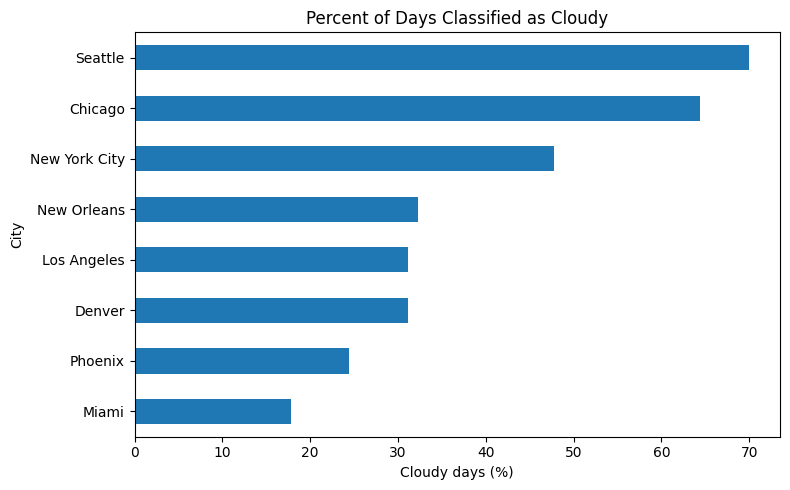

In [23]:
# This chart compares cloudy-day percentages across cities.
# It directly supports the part of Question 3 about which places were cloudy more often.
weather_pattern_by_city["is_cloudy_day"].sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Percent of Days Classified as Cloudy")
plt.xlabel("Cloudy days (%)")
plt.ylabel("City")
plt.tight_layout()
plt.show()